# Exploratory Data Analysis on Haberman Cancer Survival Dataset

This project performs Exploratory Data Analysis (EDA) on the Haberman Cancer Survival Dataset using Python libraries such as Pandas, NumPy, Matplotlib and Seaborn.

## Objectives
- Understand the dataset
- Analyze survival patterns
- Visualize feature distributions
- Compare different features
- Draw meaningful conclusions from the dataset

In [3]:
# Importing required libraries for data analysis and visualization.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Reading the haberman cancer survival dataset using pandas.
cancer=pd.read_csv("haberman.csv")

## Dataset Information

The dataset contains information about patients who underwent surgery for breast cancer.

### Features
- Age → Age of patient
- Year → Year of operation
- Nodes → Number of positive axillary nodes detected
- Status:
    - 1 = Survived 5 years or longer
    - 2 = Died within 5 years

In [5]:
# Checking the number of rows and columns in the dataset.
np.shape(cancer)

(306, 4)

In [6]:
# Displaying the feature names (column names) in the dataset
print(cancer.columns)

Index(['AGE', 'YEAR', 'NODES', 'STATUS'], dtype='object')


In [7]:
# Counting the number of datapoints for each status
cancer["STATUS"].value_counts()

,count
STATUS,
1,225
2,81


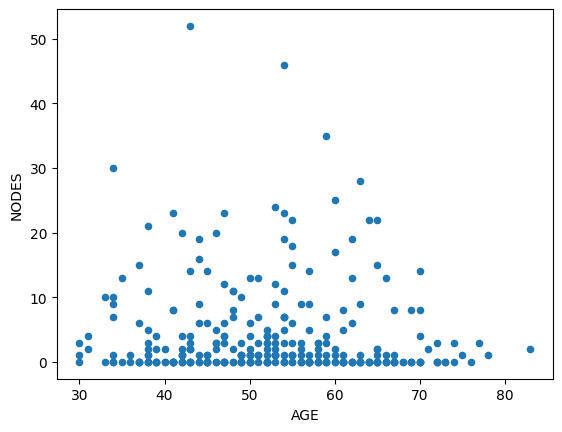

In [8]:
# Scatter plot between age and nodes
cancer.plot(kind="scatter",x="AGE",y="NODES")
# Used to visualize the relationship between two features
plt.show()

*   In the above scatter plot, it is difficult to identify which data points belong to which status.

*   So, we use the Seaborn library to assign different colors to different status using the hue parameter.

*   This helps in better visualization and understanding of class separation between status.



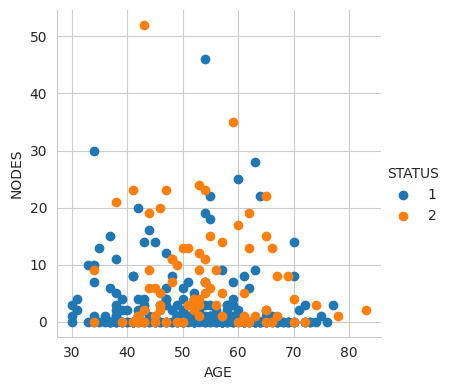

In [9]:
# Using seaborn FacetGrid for colored scatter plotting
# Different colors represent different status
# hue ='STATUS' assigns different colors to different status
sns.set_style("whitegrid")
sns.FacetGrid(cancer, hue="STATUS", height=4) \
   .map(plt.scatter,"AGE","NODES") \
   .add_legend()
plt.show()

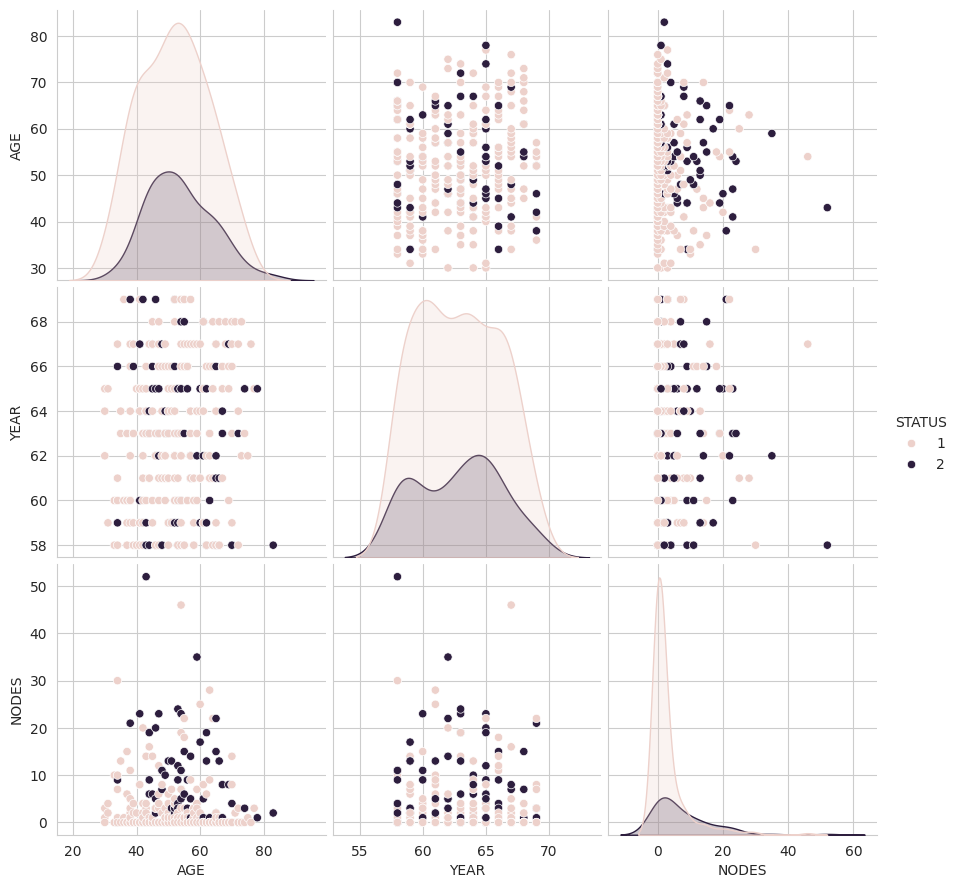

In [10]:
# Pairplots are used for multivariate analysis in EDA(Exploratory data analysis)
# Diagonal plots show feature distributions
# Non-diagonal plots show relationships between feature pairs
sns.set_style("whitegrid")
sns.pairplot(cancer, hue="STATUS", height=3)
plt.show()

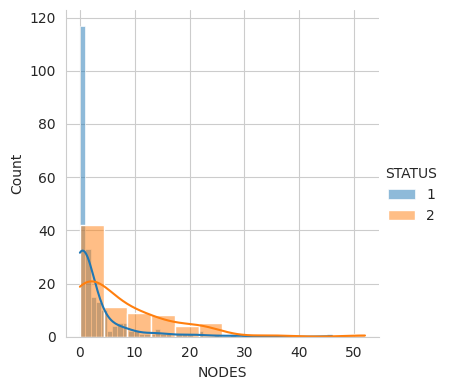

In [11]:
# Histogram of nodes for different status
# X-axis represents lymph nodes values
# Y-axis represents the number of data points in each range/bin
sns.FacetGrid(cancer, hue="STATUS", height=4 ) \
   .map(sns.histplot,"NODES",kde="True") \
   .add_legend()
plt.show()

Probability Density Function (PDF):

*   It is the smoothed form of histogram
*   It uses Kernel Density Estimation (KDE) for plotting PDF's



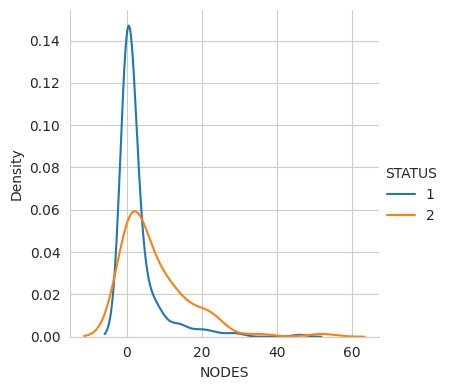

In [12]:
# PDF (Probability Density Function) of lymph nodes
# Shows how data points are distributed across values
sns.FacetGrid(cancer, hue="STATUS", height=4) \
   .map(sns.kdeplot, "NODES") \
   .add_legend()

plt.show()

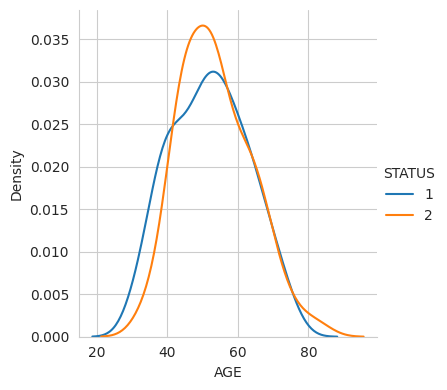

In [13]:
# PDF of age
sns.FacetGrid(cancer, hue="STATUS", height=4) \
   .map(sns.kdeplot, "AGE") \
   .add_legend()

plt.show()

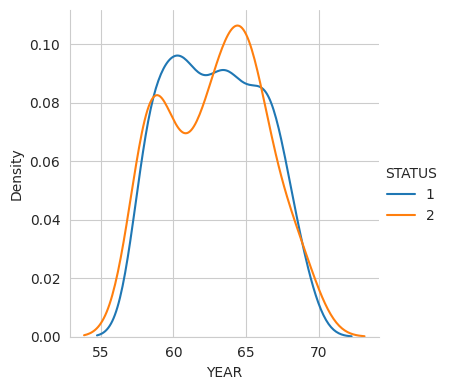

In [14]:
# PDF of year
sns.FacetGrid(cancer, hue="STATUS", height=4) \
   .map(sns.kdeplot, "YEAR") \
   .add_legend()

plt.show()

**Univariate Analysis:**

*   The nodes feature provides better separation compared to age and year.

*   Patients with fewer positive nodes had higher survival chances.



**Cumulative Distribution Function (CDF):**


*   It Shows how much percentage of the data lies up to the certain point.

*  The data is divided into bins.



[0.77124183 0.09803922 0.05882353 0.02614379 0.02941176 0.00653595
 0.00326797 0.         0.00326797 0.00326797]
[ 0.   5.2 10.4 15.6 20.8 26.  31.2 36.4 41.6 46.8 52. ]


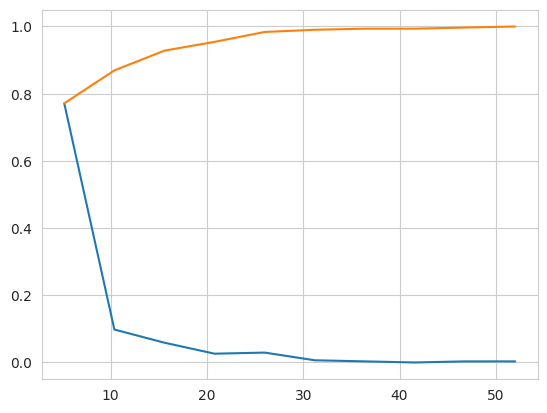

In [15]:
# counts -> number of data points present in each bin
# CDF shows the total probability up to a given value
counts,bin_edges=np.histogram(cancer["NODES"],bins=10,density=True)
pdf=counts/sum(counts)
# PDF -> probability distribution of data points
print(pdf)
print(bin_edges)
# CDF -> cumulative sum of PDF
cdf=np.cumsum(pdf)
plt.plot(bin_edges[1:],pdf)
plt.plot(bin_edges[1:],cdf)
plt.show()

In [16]:
# Mean represents the average value of the feature.
# Mean is sensitive to outliers.
print("Means:")
cancer_status1=cancer[cancer["STATUS"]==1]
cancer_status2=cancer[cancer["STATUS"]==2]
print(np.mean(cancer_status1['NODES']))
print(np.mean(cancer_status2['NODES']))

# Standard deviation measures the spread of the data.
# Small standard deviation -> data points are close to the mean.
# Large standard deviation -> data points are widely spread.
# Std is also sensitive for Outliers.
print("\n Std-Deviations:")
print(np.std(cancer_status1["NODES"]))
print(np.std(cancer_status2['NODES']))

Means:
2.7911111111111113
7.45679012345679

 Std-Deviations:
5.857258449412131
9.128776076761632


In [17]:
# Median represents the middle value of the dataset
# Median is less affected by outliers
print("Medians:")
print(np.median(cancer_status1['NODES']))
print(np.median(cancer_status2['NODES']))

# Percentiles and Quartiles indicate the percentage of data below a given value
print("\nPercentiles:")
print(np.percentile(cancer_status1['NODES'],90))
print(np.percentile(cancer_status2['NODES'],90))

print("\nQuartiles:")
print(np.percentile(cancer_status1['NODES'],np.arange(0,100,25)))
print(np.percentile(cancer_status2['NODES'],np.arange(0,100,25)))

from statsmodels import robust
print("\nMeadian Absolute Deviations:")
print(robust.mad(cancer_status1['NODES']))
print(robust.mad(cancer_status2['NODES']))

Medians:
0.0
4.0

 Percentiles:
8.0
20.0

Quartiles:
[0. 0. 0. 3.]
[ 0.  1.  4. 11.]

 Meadian Absolute Deviations:
0.0
5.930408874022408


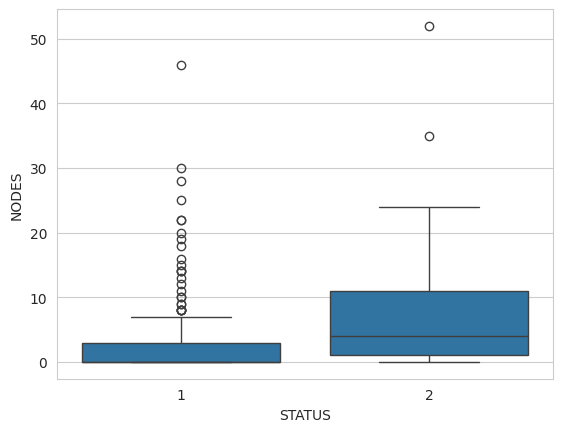

In [18]:
# Box plot shows median, quartiles, and outliers
# Useful for understanding data spread and detecting outliers
sns.boxplot(x='STATUS',y='NODES',data=cancer)
plt.show()

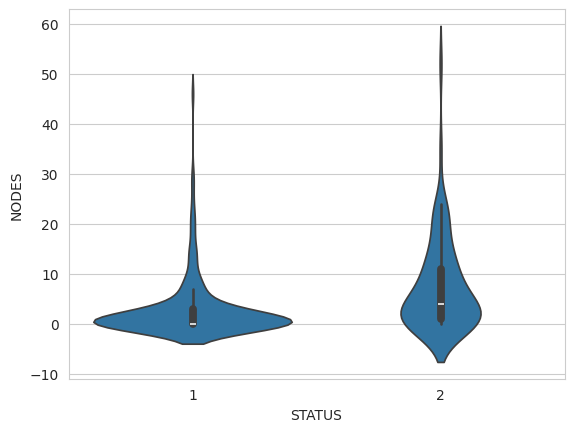

In [19]:
# Violin plot combines box plot and PDF
# Shows both distribution and density of the data
sns.violinplot(x='STATUS',y='NODES',data=cancer)
plt.show()

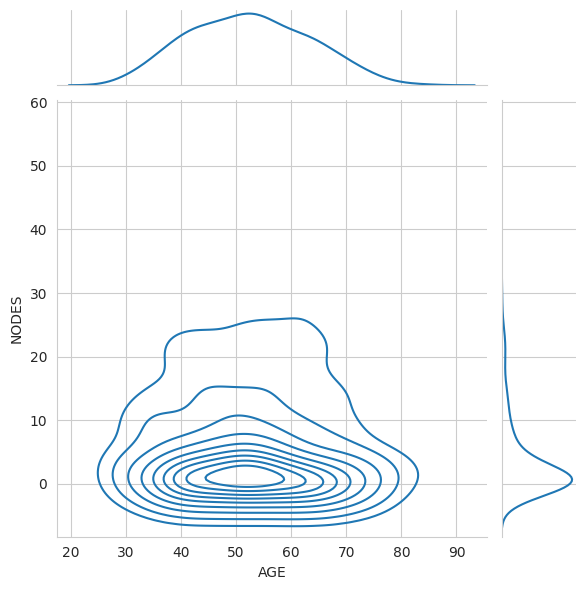

In [20]:
# Joint plot shows both scatter plot and distribution together
# Useful for understanding relationships between two features
sns.jointplot(x='AGE',y='NODES',data=cancer,kind='kde')
plt.show()

# Conclusion
- Nodes feature provides the best separation between survival classes.
- Patients with fewer positive nodes had better survival chances.
- Age and operation year are weak features for classification.
- The dataset is not perfectly linearly separable.
- Data visualization techniques helped understand important patterns in the dataset.

# Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

# Final Outcome

EDA helped in understanding the dataset before applying Machine Learning models.